# Capstone Project- GROUP 5
# Loan Default Prediction using Machine Learning Techniques
## Batch Members:
# 1. Soham Das
# 2. Satyam Golhani
# 3. Karthikeyan D
# 4. Mohammad Illyas
# Batch Mentor : Vidhya Kannaiah

In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
pd.set_option("display.max_columns",None)

In [5]:
df=pd.read_csv('prosperLoanData.csv')

In [6]:
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperRating (Alpha),ProsperScore,ListingCategory (numeric),BorrowerState,Occupation,EmploymentStatus,EmploymentStatusDuration,IsBorrowerHomeowner,CurrentlyInGroup,GroupKey,DateCreditPulled,CreditScoreRangeLower,CreditScoreRangeUpper,FirstRecordedCreditLine,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeRange,IncomeVerifiable,StatedMonthlyIncome,LoanKey,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,LoanOriginationDate,LoanOriginationQuarter,MemberKey,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,NaN,NaN,NaN,NaN,NaN,NaN,0,CO,Other,Self-employed,2.0,True,True,NaN,2007-08-26 18:41:46.780000000,640.0,659.0,2001-10-11 00:00:00,5.0,4.0,12.0,1,24.0,3.0,3.0,2.0,472.0,4.0,0.0,0.0,0.0,0.00,1500.0,11.0,0.81,0.0,0.17,"$25,000-49,999",True,3083.333333,E33A3400205839220442E84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,78,19141,9425,2007-09-12 00:00:00,Q3 2007,1F3E3376408759268057EDA,330.43,11396.14,9425.00,1971.14,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,0.07960,0.0249,0.05470,6.0,A,7.0,2,CO,Professional,Employed,44.0,False,False,NaN,2014-02-27 08:28:14,680.0,699.0,1996-03-18 00:00:00,14.0,14.0,29.0,13,389.0,3.0,5.0,0.0,0.0,0.0,1.0,0.0,3989.0,0.21,10266.0,29.0,1.00,2.0,0.18,"$50,000-74,999",True,6125.000000,9E3B37071505919926B1D82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,0,134815,10000,2014-03-03 00:00:00,Q1 2014,1D13370546739025387B2F4,318.93,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,NaN,NaN,NaN,NaN,NaN,NaN,0,GA,Other,Not available,NaN,False,True,783C3371218786870A73D20,2007-01-02 14:09:10.060000000,480.0,499.0,2002-07-27 00:00:00,NaN,NaN,3.0,0,0.0,0.0,1.0,1.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.06,Not displayed,True,2083.333333,6954337960046817851BCB2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,86,6466,3001,2007-01-17 00:00:00,Q1 2007,5F7033715035555618FA612,123.32,4186.63,3001.00,1185.63,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,0.08490,0.0249,0.06000,6.0,A,9.0,16,GA,Skilled Labor,Employed,113.0,True,False,NaN,2012-10-22 11:02:32,800.0,819.0,1983-02-28 00:00:00,5.0,5.0,29.0,7,115.0,0.0,1.0,4.0,10056.0,14.0,0.0,0.0,1444.0,0.04,30754.0,26.0,0.76,0.0,0.15,"$25,000-49,999",True,2875.000000,A0393664465886295619C51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,16,77296,10000,2012-11-01 00:00:00,Q4 2012,9ADE356069835475068C6D2,321.45,5143.20,4091.09,1052.11,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,0.18316,0.0925,0.09066,3.0,D,4.0,2,MN

In [7]:
df.shape

(113937, 81)

In [8]:
df.dtypes

ListingKey                      object
ListingNumber                    int64
ListingCreationDate             object
CreditGrade                     object
Term                             int64
                                ...   
PercentFunded                  float64
Recommendations                  int64
InvestmentFromFriendsCount       int64
InvestmentFromFriendsAmount    float64
Investors                        int64
Length: 81, dtype: object

In [9]:
df.describe()

,ListingNumber,Term,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperScore,ListingCategory (numeric),EmploymentStatusDuration,CreditScoreRangeLower,CreditScoreRangeUpper,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,StatedMonthlyIncome,TotalProsperLoans,TotalProsperPaymentsBilled,OnTimeProsperPayments,ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsOneMonthPlusLate,ProsperPrincipalBorrowed,ProsperPrincipalOutstanding,ScorexChangeAtTimeOfListing,LoanCurrentDaysDelinquent,LoanFirstDefaultedCycleNumber,LoanMonthsSinceOrigination,LoanNumber,LoanOriginalAmount,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
count,1.139370e+05,113937.000000,113912.000000,113937.000000,113937.000000,84853.000000,84853.000000,84853.000000,84853.000000,84853.000000,113937.000000,106312.000000,113346.000000,113346.000000,106333.000000,106333.000000,113240.000000,113937.00000,113937.000000,113240.000000,112778.000000,113240.000000,106315.000000,112947.000000,113240.000000,106333.000000,1.063330e+05,106333.000000,106393.000000,106393.000000,106393.000000,106393.000000,105383.000000,1.139370e+05,22085.000000,22085.000000,22085.000000,22085.000000,22085.000000,22085.000000,22085.000000,18928.000000,113937.000000,16952.000000,113937.000000,113937.000000,113937.00000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000,113937.000000
mean,6.278857e+05,40.830248,0.218828,0.192764,0.182701,0.168661,0.080306,0.096068,4.072243,5.950067,2.774209,96.071582,685.567731,704.567731,10.317192,9.260164,26.754539,6.96979,398.292161,1.435085,5.584405,0.592052,984.507059,4.154984,0.312646,0.015094,1.759871e+04,0.561309,11210.225447,23.230034,0.885897,0.802327,0.275947,5.608026e+03,1.421100,22.934345,22.271949,0.613629,0.048540,8472.311961,2930.313906,-3.223214,152.816539,16.268464,31.896882,69444.474271,8337.01385,272.475783,4183.079489,3105.536588,1077.542901,-54.725641,-14.242698,700.446342,681.420499,25.142686,0.998584,0.048027,0.023460,16.550751,80.475228
std,3.280762e+05,10.436212,0.080364,0.074818,0.074516,0.068467,0.046764,0.030403,1.673227,2.376501,3.996797,94.480605,66.458275,66.458275,5.457866,5.022644,13.637871,4.63097,447.159711,2.437507,6.429946,1.978707,7158.270157,10.160216,0.727868,0.154092,3.293640e+04,0.317918,19818.361309,11.871311,0.148179,1.097637,0.551759,7.478497e+03,0.764042,19.249584,18.830425,2.446827,0.556285,7395.507650,3806.635075,50.063567,466.320254,9.005898,29.974184,38930.479610,6245.80058,192.697812,4790.907234,4069.527670,1183.414168,60.675425,109.232758,2388.513831,2357.167068,275.657937,0.017919,0.332353,0.232412,294.545422,103.239020
min,4.000000e+00,12.000000,0.006530,0.000000,-0.010000,-0.182700,0.004900,-0.182700,1.000000,1.000000,0.000000,0.000000,0.000000,19.000000,0.000000,0.000000,2.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-209.000000,0.000000,0.000000,0.000000,1.000000,1000.00000,0.000000,-2.349900,0.000000,-2.349900,-664.870000,-9274.750000,-94.200000,-954.550000,0.000000,0.700000,0.000000,0.000000,0.000000,1.000000
25%,4.009190e+05,36.000000

In [10]:
# Duplicates data entry in loan data
df.duplicated().sum()

0

In [11]:
df.isnull().sum().sum()

1364086

In [12]:
df.isnull().sum()

ListingKey                         0
ListingNumber                      0
ListingCreationDate                0
CreditGrade                    84984
Term                               0
                               ...  
PercentFunded                      0
Recommendations                    0
InvestmentFromFriendsCount         0
InvestmentFromFriendsAmount        0
Investors                          0
Length: 81, dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

In [14]:
df['LoanOriginationDate'] = pd.to_datetime(df['LoanOriginationDate'])

In [15]:
df_loan = df.copy()

In [16]:
## Univariate Data Analysis

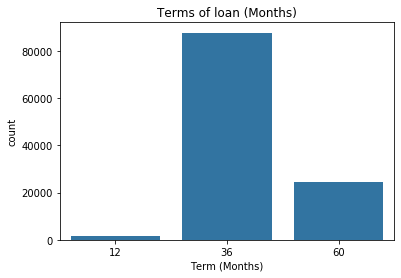

In [17]:
# Loan by term
base_color = sns.color_palette()[0]
sns.countplot(data=df_loan,x= 'Term',color=base_color);
plt.title('Terms of loan (Months)')
plt.xlabel('Term (Months)');

In [18]:
type_count = df_loan['LoanStatus'].value_counts()
type_order = type_count.index

In [19]:
# Count of Loan by Loan Status
n_loan =df_loan.shape[0]
max_type_count = type_count[0]
max_prop = max_type_count/n_loan

In [20]:
tick_props = np.arange(0,max_prop,0.1)
tick_names = ['{:0.2f}'.format(v) for v in tick_props]

In [21]:
tick_names

['0.00', '0.10', '0.20', '0.30', '0.40']

Text(0.5, 1.0, 'Proportion of Loan Status')

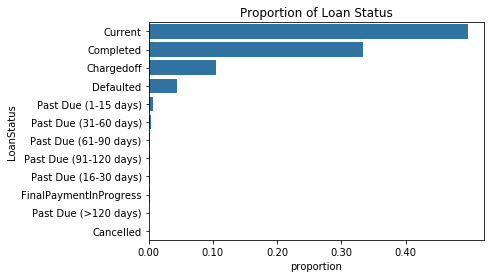

In [22]:
sns.countplot(data=df_loan,y='LoanStatus',color=base_color,order=type_order);
plt.xticks(tick_props*n_loan,tick_names)
plt.xlabel('proportion');
plt.title('Proportion of Loan Status')

Text(0.5, 1.0, 'Count of Prosper ratings')

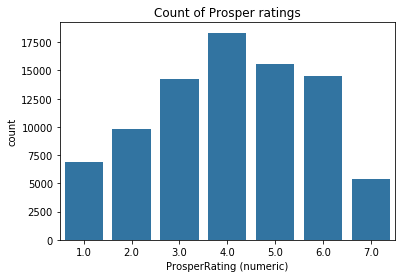

In [23]:
# Distribution of Prosper rating
sns.countplot(data=df_loan,x='ProsperRating (numeric)',color=base_color);
plt.title('Count of Prosper ratings')

In [24]:
df_loan['Year'] = df_loan['LoanOriginationQuarter'].str[-4:]

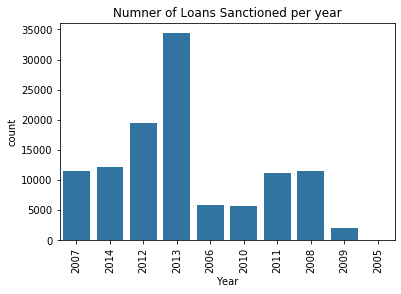

In [25]:
# Number of loans per year
sns.countplot(data=df_loan,x='Year',color=base_color);
plt.title('Numner of Loans Sanctioned per year')
plt.xticks(rotation=90);

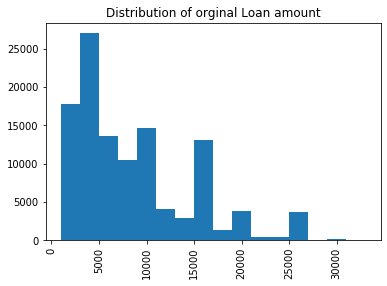

In [26]:
# Distribution of orginal Loan amount
bins = np.arange(1000,35000,2000)
plt.hist(data=df_loan,x='LoanOriginalAmount',color=base_color,bins=bins);
plt.title('Distribution of orginal Loan amount')
plt.xticks(rotation=90);

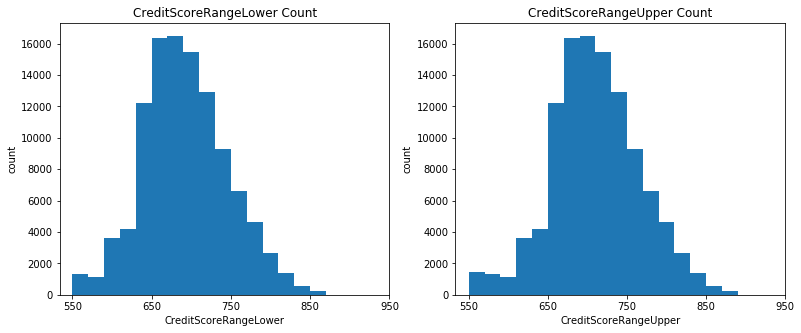

In [27]:
# Histogram for Credit Score ranges

plt.figure(figsize = [13, 5]) 


plt.subplot(1, 2, 1)
bins = np.arange(550, df_loan['CreditScoreRangeLower'].max(), 20)
plt.hist(data = df_loan, x = 'CreditScoreRangeLower', bins = bins)
plt.xticks(np.arange(550, 1000, 100))
plt.title('CreditScoreRangeLower Count')
plt.xlabel('CreditScoreRangeLower')
plt.ylabel('count');

plt.subplot(1, 2, 2)
bins = np.arange(550, df_loan['CreditScoreRangeUpper'].max(), 20)
plt.hist(data = df_loan, x = 'CreditScoreRangeUpper', bins = bins)
plt.xticks(np.arange(550, 1000, 100))
plt.title('CreditScoreRangeUpper Count')
plt.xlabel('CreditScoreRangeUpper')
plt.ylabel('count');

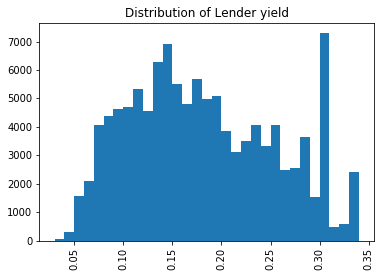

In [28]:
# Distribution of lender yield
bins = np.arange(.03,.34,.01)
plt.hist(data=df_loan,x='LenderYield',color=base_color,bins=bins);
plt.title('Distribution of Lender yield')
plt.xticks(rotation=90);

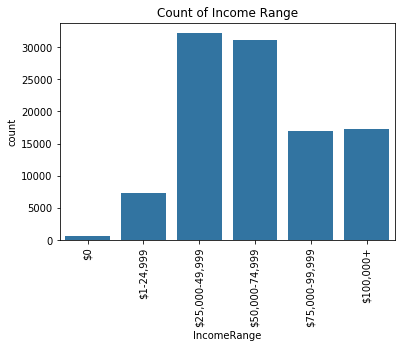

In [29]:
# Income range of borrower
order = ['$0','$1-24,999','$25,000-49,999','$50,000-74,999','$75,000-99,999','$100,000+']
sns.countplot(data=df_loan,x='IncomeRange',color=base_color,order=order);
plt.title('Count of Income Range')
plt.xticks(rotation=90);

In [30]:
## Bivariate Data Analysis

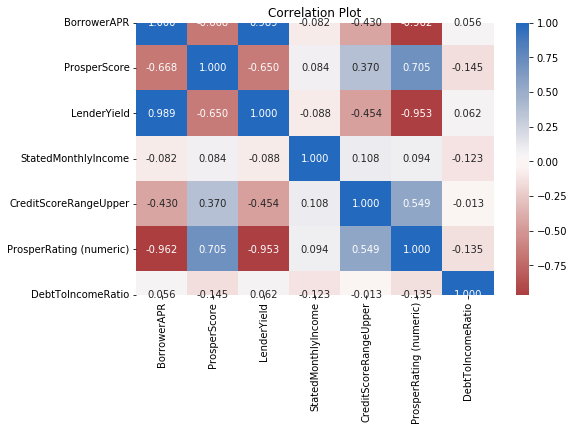

In [31]:
# correlation plot 

num_vars = ['BorrowerAPR', 'ProsperScore', 'LenderYield', 
            'StatedMonthlyIncome',  'CreditScoreRangeUpper','ProsperRating (numeric)','DebtToIncomeRatio']
plt.figure(figsize = [8, 5])
sns.heatmap(df_loan[num_vars].corr(), annot = True, fmt = '.3f',
           cmap = 'vlag_r', center = 0)
plt.title('Correlation Plot') 
plt.show()

In [32]:
# plot matrix: only 300 random loans are used to see the pattern more clearer

# sns.pairplot(df_loan)

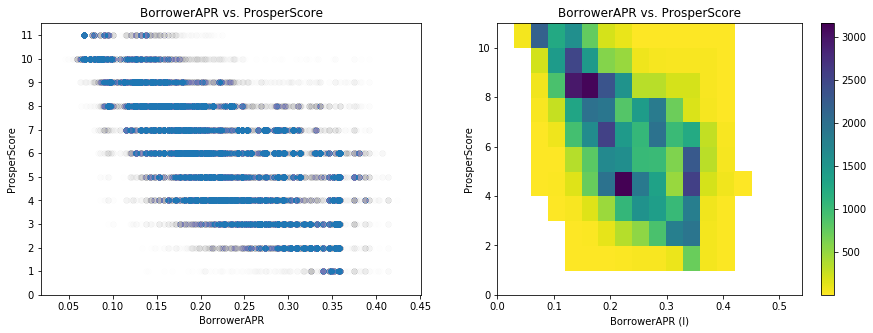

In [33]:
# scatter and heat plot for comparing ProsperScore and BorrowerAPR. 
plt.figure(figsize = [15, 5]) 

plt.subplot(1, 2, 1)
plt.scatter(data = df_loan, x = 'BorrowerAPR', y = 'ProsperScore', alpha =  0.005)
plt.yticks(np.arange(0, 12, 1))
plt.title('BorrowerAPR vs. ProsperScore')
plt.xlabel('BorrowerAPR')
plt.ylabel('ProsperScore')


plt.subplot(1, 2, 2)
bins_x = np.arange(0, df_loan['BorrowerAPR'].max()+0.05, 0.03)
bins_y = np.arange(0, df_loan['ProsperScore'].max()+1, 1)
plt.hist2d(data = df_loan, x = 'BorrowerAPR', y = 'ProsperScore', bins = [bins_x, bins_y], 
               cmap = 'viridis_r', cmin = 0.5)
plt.colorbar()
plt.title('BorrowerAPR vs. ProsperScore')
plt.xlabel('BorrowerAPR (l)')
plt.ylabel('ProsperScore');

Here the relationship is evident, higher the prosper score is lower is Borrower APR and this makes sense because lower the risk attached with the borrower lower will be the APR.

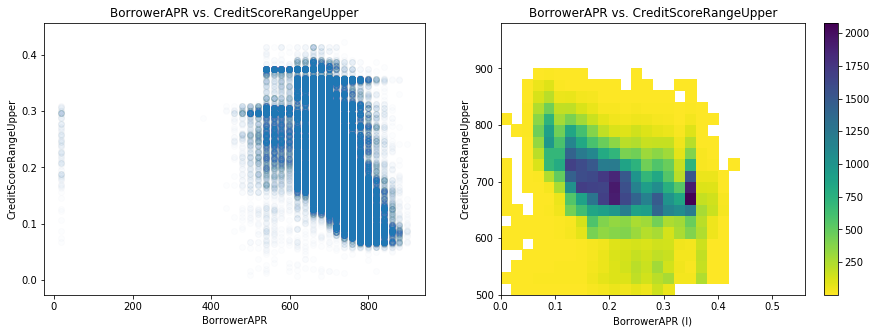

In [34]:
# scatter and heat plot for comparing BorrowerAPR and credit score upper range. 
plt.figure(figsize = [15, 5]) 

plt.subplot(1, 2, 1)
plt.scatter(data = df_loan, x = 'CreditScoreRangeUpper', y = 'BorrowerAPR', alpha = 0.01)
plt.title('BorrowerAPR vs. CreditScoreRangeUpper')
plt.xlabel('BorrowerAPR')
plt.ylabel('CreditScoreRangeUpper');


plt.subplot(1, 2, 2)
bins_x = np.arange(0, df_loan['BorrowerAPR'].max()+0.05, 0.02)
bins_y = np.arange(500, df_loan['CreditScoreRangeUpper'].max()+100, 20)
plt.hist2d(data = df_loan, x = 'BorrowerAPR', y = 'CreditScoreRangeUpper', bins = [bins_x, bins_y], 
               cmap = 'viridis_r', cmin = 0.5)

plt.colorbar()
plt.title('BorrowerAPR vs. CreditScoreRangeUpper')
plt.xlabel('BorrowerAPR (l)')
plt.ylabel('CreditScoreRangeUpper');

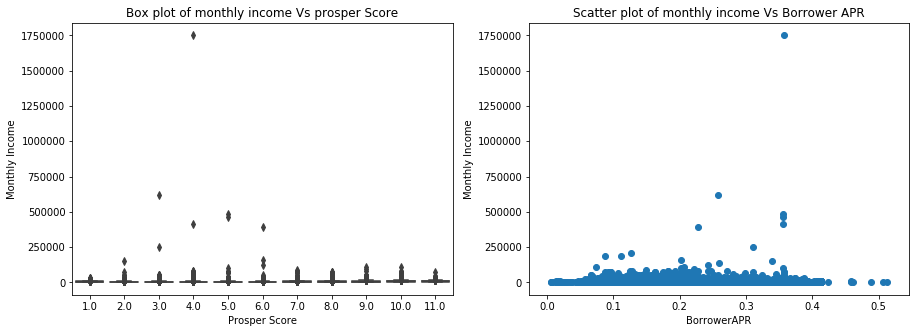

In [35]:
# Stated MonthlyIncome vs Prosper Rating
plt.figure(figsize = [15, 5])

plt.subplot(1, 2, 1)
sns.boxplot(data=df_loan,x='ProsperScore',y='StatedMonthlyIncome',color=base_color);
plt.xlabel('Prosper Score');
plt.ylabel('Monthly Income');
plt.title('Box plot of monthly income Vs prosper Score');

plt.subplot(1, 2, 2)
plt.scatter(data=df_loan,x='BorrowerAPR',y='StatedMonthlyIncome',color=base_color);
plt.xlabel('BorrowerAPR');
plt.ylabel('Monthly Income');
plt.title('Scatter plot of monthly income Vs Borrower APR');

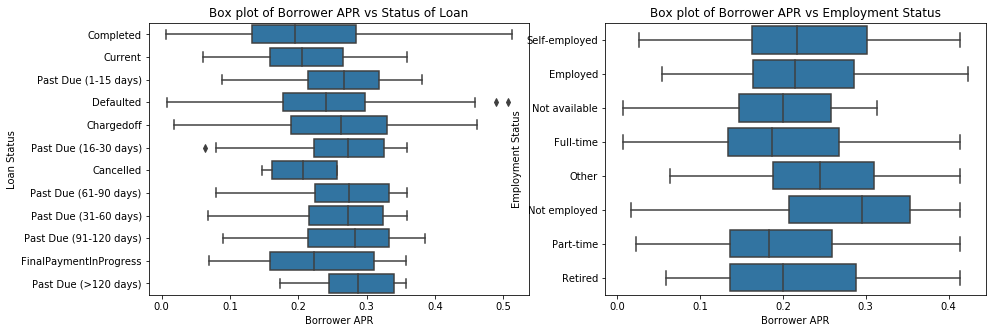

In [36]:
# Borrower APR vs Status of Loan and  Borrower APR vs Employment status
plt.figure(figsize = [15, 5])

plt.subplot(1, 2, 1)
sns.boxplot(data=df_loan,x='BorrowerAPR',y='LoanStatus',color=base_color);
plt.xlabel('Borrower APR');
plt.ylabel('Loan Status');
plt.title('Box plot of Borrower APR vs Status of Loan');

plt.subplot(1, 2, 2)
sns.boxplot(data=df_loan,x='BorrowerAPR',y='EmploymentStatus',color=base_color);
plt.xlabel('Borrower APR');
plt.ylabel('Employment Status');
plt.title('Box plot of Borrower APR vs Employment Status');

In [37]:
df_series = df_loan['BorrowerRate'].groupby(df_loan['LoanOriginationQuarter']).mean().reset_index()

In [38]:
df_series.LoanOriginationQuarter = pd.Categorical(df_series.LoanOriginationQuarter, sorted(df_series.LoanOriginationQuarter, key=lambda x: x.split(' ')[-1]), ordered = True)
df_series.sort_values('LoanOriginationQuarter', inplace=True)

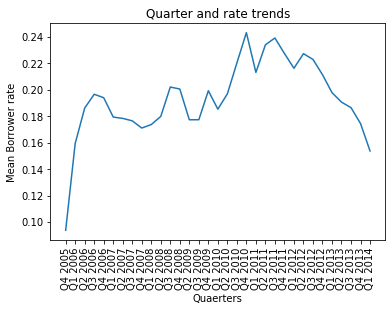

In [39]:
# Mean Borrower rate over time
plt.errorbar(data=df_series,x='LoanOriginationQuarter',y='BorrowerRate');
plt.xticks(rotation = 90);
plt.xlabel('Quaerters');
plt.ylabel('Mean Borrower rate');
plt.title('Quarter and rate trends');

## Multivariate Data Analysis

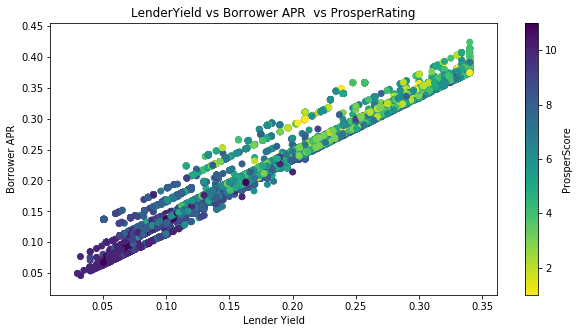

In [40]:
# LenderYield vs Borrower APR  vs ProsperRating
plt.figure(figsize = [10, 5])
plt.scatter(data=df_loan,x='LenderYield',y = 'BorrowerAPR',c='ProsperScore',cmap = 'viridis_r')
plt.colorbar(label = 'ProsperScore');
plt.xlabel('Lender Yield')
plt.ylabel('Borrower APR')
plt.title('LenderYield vs Borrower APR  vs ProsperRating');

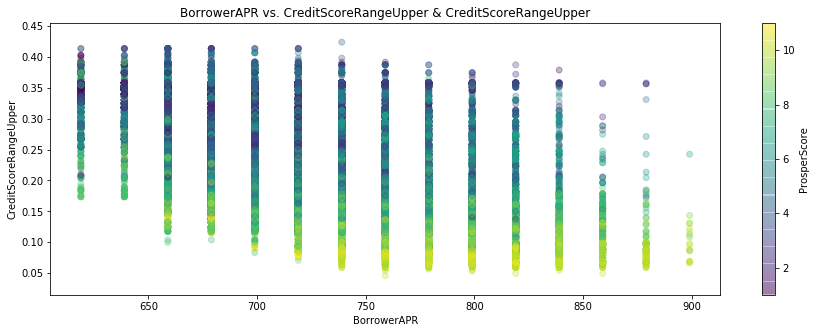

In [41]:
# BorrowerAPR vs. CreditScoreRangeUpper & CreditScoreRangeUpper
plt.figure(figsize = [15, 5]) 
plt.scatter(data = df_loan, x = 'CreditScoreRangeUpper', y = 'BorrowerAPR', c ='ProsperScore', alpha = 0.3)
plt.colorbar(label = 'ProsperScore')
plt.title('BorrowerAPR vs. CreditScoreRangeUpper & CreditScoreRangeUpper')
plt.xlabel('BorrowerAPR')
plt.ylabel('CreditScoreRangeUpper');

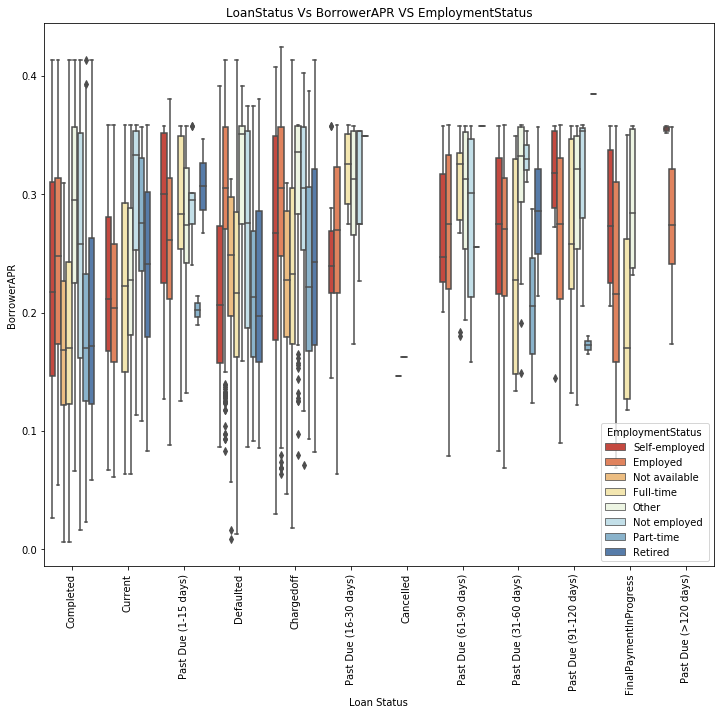

In [42]:
# LoanStatus Vs BorrowerAPR VS EmploymentStatus
plt.figure(figsize=[12,10])
sns.boxplot(x="LoanStatus", y="BorrowerAPR", hue="EmploymentStatus", data=df_loan, palette="RdYlBu");
plt.xticks(rotation = 90);
plt.xlabel('Loan Status');
plt.ylabel('BorrowerAPR');
plt.title('LoanStatus Vs BorrowerAPR VS EmploymentStatus');

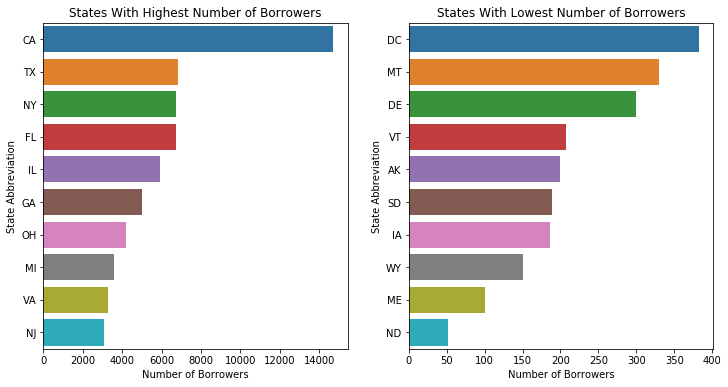

In [43]:
most_state_list = df_loan['BorrowerState'].value_counts()[:10].index.tolist()
most_state_count = df_loan['BorrowerState'].value_counts()[:10].values.tolist()

least_state_list = df_loan['BorrowerState'].value_counts()[-10:].index.tolist()
least_state_count = df_loan['BorrowerState'].value_counts()[-10:].values.tolist()

f,(ax1,ax2) = plt.subplots(ncols=2, sharey=False, sharex=False,
                          figsize=(12,6))

sns.barplot(x=most_state_count, y=most_state_list, ax=ax1)
ax1.set_title('States With Highest Number of Borrowers')
ax1.set_xlabel('Number of Borrowers')
ax1.set_ylabel('State Abbreviation')

sns.barplot(x=least_state_count, y=least_state_list, ax=ax2)
ax2.set_title('States With Lowest Number of Borrowers')
ax2.set_xlabel('Number of Borrowers')
ax2.set_ylabel('State Abbreviation')
plt.show()

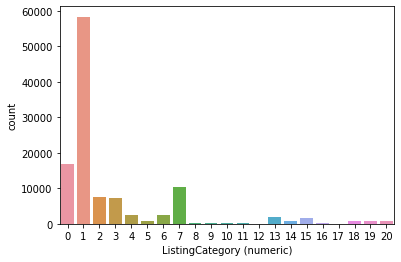

In [44]:
# fig = plt.figure(figsize=(12,6))
sns.countplot(df_loan["ListingCategory (numeric)"])

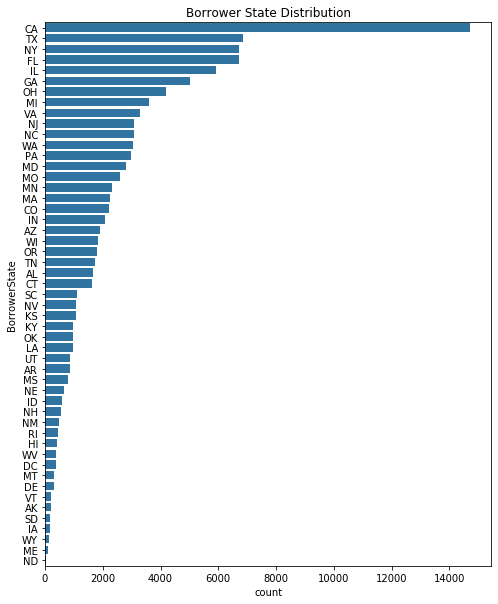

In [45]:
#Borrower State Distrobution
cat_order = df_loan.BorrowerState.value_counts().index
plt.figure(figsize=[8, 10])
sns.countplot(data=df_loan,y='BorrowerState',color=base_color, order=cat_order);
plt.title('Borrower State Distribution');

(array([    0., 10000., 20000., 30000., 40000., 50000., 60000., 70000.]),
 <a list of 8 Text xticklabel objects>)

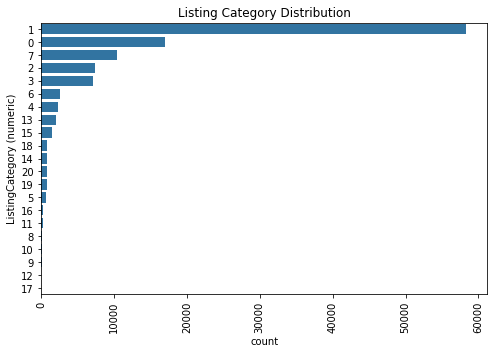

In [46]:
#Listing Category Distrobution
cat_order = df_loan["ListingCategory (numeric)"].value_counts().index
plt.figure(figsize=[8, 5])
sns.countplot(data=df_loan,y='ListingCategory (numeric)',color=base_color, order=cat_order);
plt.title('Listing Category Distribution')
plt.xticks(rotation=90)

# add annotations
# n_points = df_loan.shape[0]
# cat_counts = df_loan['ListingCategory (numeric)'].value_counts()
# locs, labels = plt.yticks() # get the current tick locations and labels

# # loop through each pair of locations and labels
# for loc, label in zip(locs, labels):

#     # get the text property for the label to get the correct count
#     count = cat_counts[label.get_text()]
#     pct_string = '{:0.0f}%'.format(100*count/n_points)

#     # print the annotation just below the top of the bar
#     plt.text(count+1400, loc+0.3,  pct_string, ha = 'center', color = 'black');

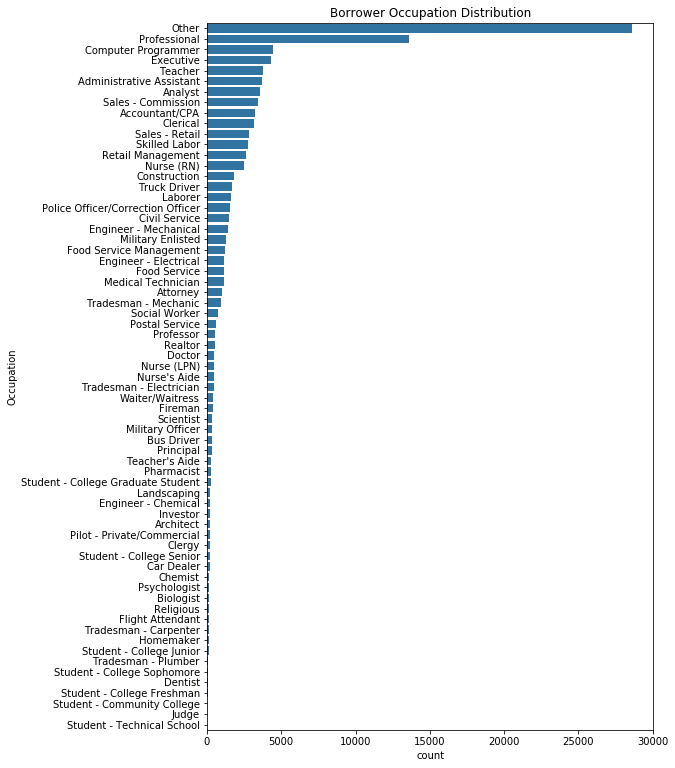

In [47]:
#Borrower Occupation Distrobution
cat_order = df_loan.Occupation.value_counts().index
plt.figure(figsize=[8, 13])
sns.countplot(data=df_loan,y='Occupation',color=base_color, order=cat_order);
plt.title('Borrower Occupation Distribution');

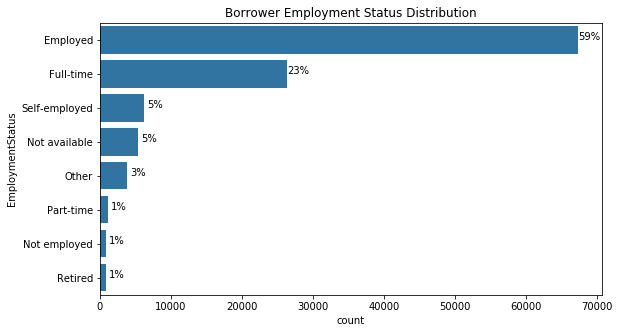

In [48]:
#Borrower Employment Status Distrobution
cat_order = df_loan.EmploymentStatus.value_counts().index
plt.figure(figsize=[9, 5])
sns.countplot(data=df_loan,y='EmploymentStatus',color=base_color, order=cat_order);
plt.title('Borrower Employment Status Distribution')

# add annotations
n_points = df_loan.shape[0]
cat_counts = df_loan['EmploymentStatus'].value_counts()
locs, labels = plt.yticks() # get the current tick locations and labels

# loop through each pair of locations and labels
for loc, label in zip(locs, labels):

    # get the text property for the label to get the correct count
    count = cat_counts[label.get_text()]
    pct_string = '{:0.0f}%'.format(100*count/n_points)

    # print the annotation just below the top of the bar
    plt.text(count+1600, loc,  pct_string, ha = 'center', color = 'black');

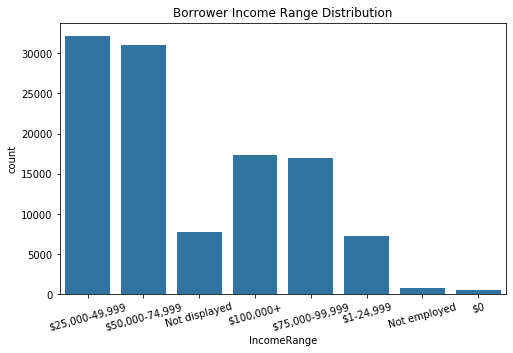

In [49]:
#Borrower Income Range Status Distrobution
plt.figure(figsize=[8, 5])
sns.countplot(data=df_loan,x='IncomeRange',color=base_color);
plt.title('Borrower Income Range Distribution')
plt.xticks(rotation=15);

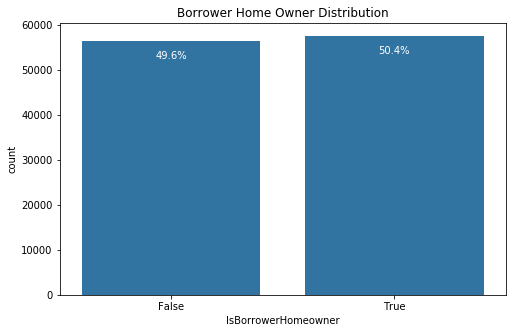

In [50]:
#Is Borrower-Homeowner Status Distrobution
plt.figure(figsize=[8, 5])

def str2bool(v):
    return str(v).lower() in ("yes", "true", "True", "1")

base_color = sns.color_palette()[0]
sns.countplot(data = df_loan, x = 'IsBorrowerHomeowner', color = base_color)

# add annotations
n_points = df_loan.shape[0]
cat_counts = df_loan['IsBorrowerHomeowner'].value_counts()
locs, labels = plt.xticks() # get the current tick locations and labels

# loop through each pair of locations and labels
for loc, label in zip(locs, labels):

    # get the text property for the label to get the correct count
    count = cat_counts[str2bool(label.get_text())]
    pct_string = '{:0.1f}%'.format(100*count/n_points)

    # print the annotation just below the top of the bar
    plt.text(loc, count-4000, pct_string, ha = 'center', color = 'w')

plt.title('Borrower Home Owner Distribution');

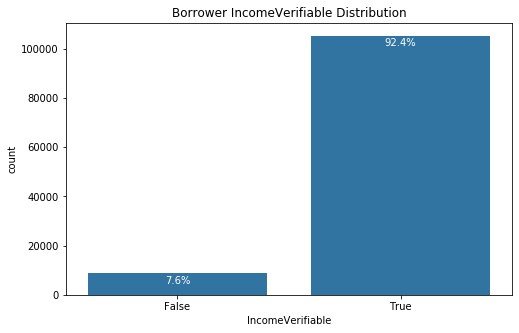

In [51]:
#Is Income-Verifiable Status Distrobution
plt.figure(figsize=[8, 5])

def str2bool(v):
    return str(v).lower() in ("yes", "true", "True", "1")

base_color = sns.color_palette()[0]
sns.countplot(data = df_loan, x = 'IncomeVerifiable', color = base_color)

# add annotations
n_points = df_loan.shape[0]
cat_counts = df_loan['IncomeVerifiable'].value_counts()
locs, labels = plt.xticks() # get the current tick locations and labels

# loop through each pair of locations and labels
for loc, label in zip(locs, labels):

    # get the text property for the label to get the correct count
    count = cat_counts[str2bool(label.get_text())]
    pct_string = '{:0.1f}%'.format(100*count/n_points)

    # print the annotation just below the top of the bar
    plt.text(loc, count-4000, pct_string, ha = 'center', color = 'w')

#sb.countplot(data=df_loans_clean,x='IsBorrowerHomeowner',color=base_color);
plt.title('Borrower IncomeVerifiable Distribution');

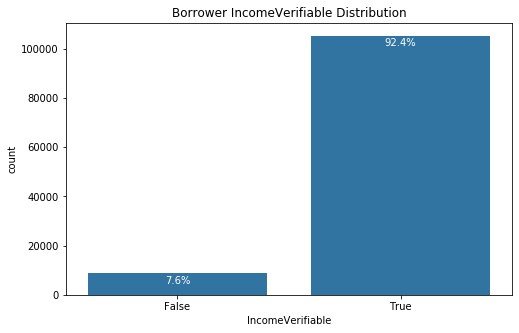

In [52]:
#Is Income-Verifiable Status Distrobution
plt.figure(figsize=[8, 5])

def str2bool(v):
    return str(v).lower() in ("yes", "true", "True", "1")

base_color = sns.color_palette()[0]
sns.countplot(data = df_loan, x = 'IncomeVerifiable', color = base_color)

# add annotations
n_points = df_loan.shape[0]
cat_counts = df_loan['IncomeVerifiable'].value_counts()
locs, labels = plt.xticks() # get the current tick locations and labels

# loop through each pair of locations and labels
for loc, label in zip(locs, labels):

    # get the text property for the label to get the correct count
    count = cat_counts[str2bool(label.get_text())]
    pct_string = '{:0.1f}%'.format(100*count/n_points)

    # print the annotation just below the top of the bar
    plt.text(loc, count-4000, pct_string, ha = 'center', color = 'w')

#sb.countplot(data=df_loans_clean,x='IsBorrowerHomeowner',color=base_color);
plt.title('Borrower IncomeVerifiable Distribution');

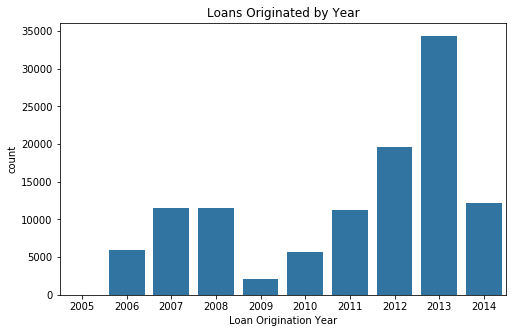

In [53]:
# Loan Origination by Year
plt.figure(figsize=[8, 5])
sns.countplot(data=df_loan,x=df_loan['LoanOriginationDate'].dt.year,color=base_color)
plt.title('Loans Originated by Year')
plt.xlabel('Loan Origination Year');

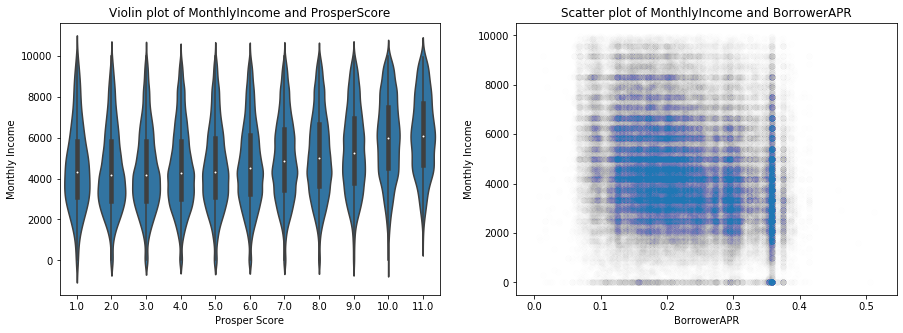

In [54]:
# Stated MonthlyIncome  Prosper Rating
# Since 75% of the data has StatedMonthlyIncome less than 6825, we can plot data within this range
df_wo_outlier=df_loan[df_loan['StatedMonthlyIncome'] < 10000]

plt.figure(figsize = [15, 5])
plt.subplot(1, 2, 1)
sns.violinplot(data=df_wo_outlier,x='ProsperScore', y='StatedMonthlyIncome',color=base_color);
plt.xlabel('Prosper Score');
plt.ylabel('Monthly Income');
plt.title('Violin plot of MonthlyIncome and ProsperScore');

plt.subplot(1, 2, 2)
plt.scatter(data=df_wo_outlier,x='BorrowerAPR', y='StatedMonthlyIncome',color=base_color, alpha =  0.005);
plt.xlabel('BorrowerAPR');
plt.ylabel('Monthly Income');
plt.title('Scatter plot of MonthlyIncome and BorrowerAPR');

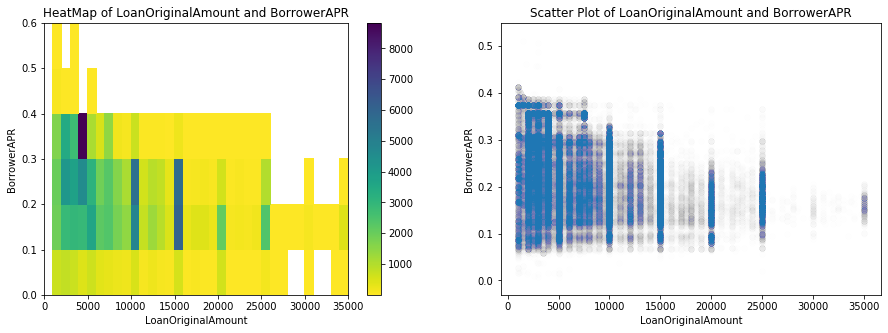

In [55]:
# Checking the relation between ProsperScore and StatedMonthlyIncome

plt.figure(figsize = [15, 5]) 


plt.subplot(1, 2, 1)
bins_x = np.arange(0, df_loan['LoanOriginalAmount'].max()+1000, 1000)
bins_y = np.arange(0, df_loan['BorrowerAPR'].max()+0.1, 0.1)
plt.hist2d(data = df_loan, x = 'LoanOriginalAmount', y = 'BorrowerAPR', bins = [bins_x, bins_y], 
               cmap = 'viridis_r', cmin = 0.5)
plt.xlabel('LoanOriginalAmount')
plt.ylabel('BorrowerAPR')
plt.title('HeatMap of LoanOriginalAmount and BorrowerAPR')

plt.colorbar()


plt.subplot(1, 2, 2)
plt.scatter(data = df_loan, x = 'LoanOriginalAmount', y = 'BorrowerAPR',  alpha =  0.005)
plt.yticks(np.arange(0, 0.6, 0.1))
plt.title('Scatter Plot of LoanOriginalAmount and BorrowerAPR')
plt.xlabel('LoanOriginalAmount')
plt.ylabel('BorrowerAPR');

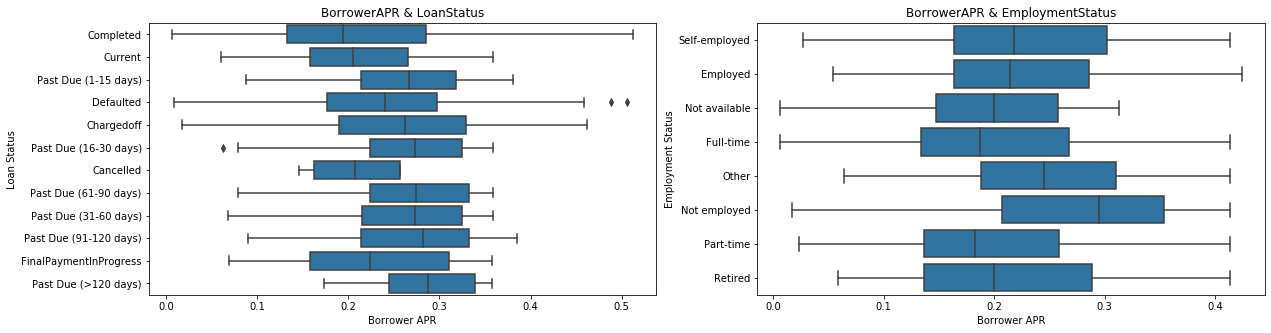

In [56]:
# Borrower APR vs Status of Loan and  Borrower APR vs Employment status
plt.figure(figsize = [20, 5])

plt.subplot(1, 2, 1)
sns.boxplot(data=df_loan,x='BorrowerAPR',y='LoanStatus',color=base_color);
plt.xlabel('Borrower APR');
plt.ylabel('Loan Status');
plt.title('BorrowerAPR & LoanStatus');

plt.subplot(1, 2, 2)
sns.boxplot(data=df_loan,x='BorrowerAPR',y='EmploymentStatus',color=base_color);
plt.xlabel('Borrower APR');
plt.ylabel('Employment Status');
plt.title('BorrowerAPR & EmploymentStatus');

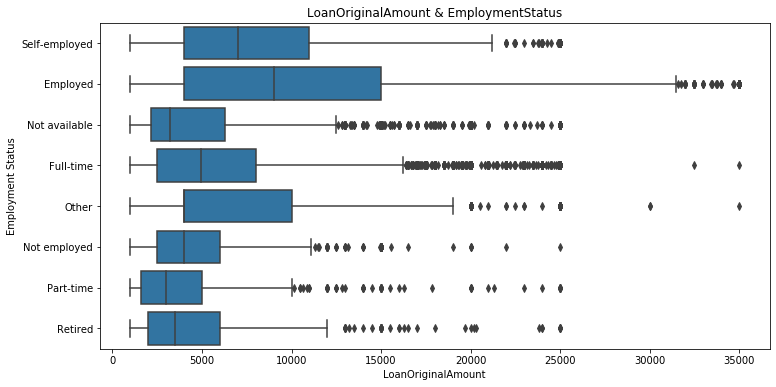

In [57]:
plt.figure(figsize = [12, 6])
sns.boxplot(data=df_loan,x='LoanOriginalAmount',y='EmploymentStatus',color=base_color);
plt.xlabel('LoanOriginalAmount');
plt.ylabel('Employment Status');
plt.title('LoanOriginalAmount & EmploymentStatus');

Text(0.5, 1.0, 'Prosper Rating Distribution for Employment Status')

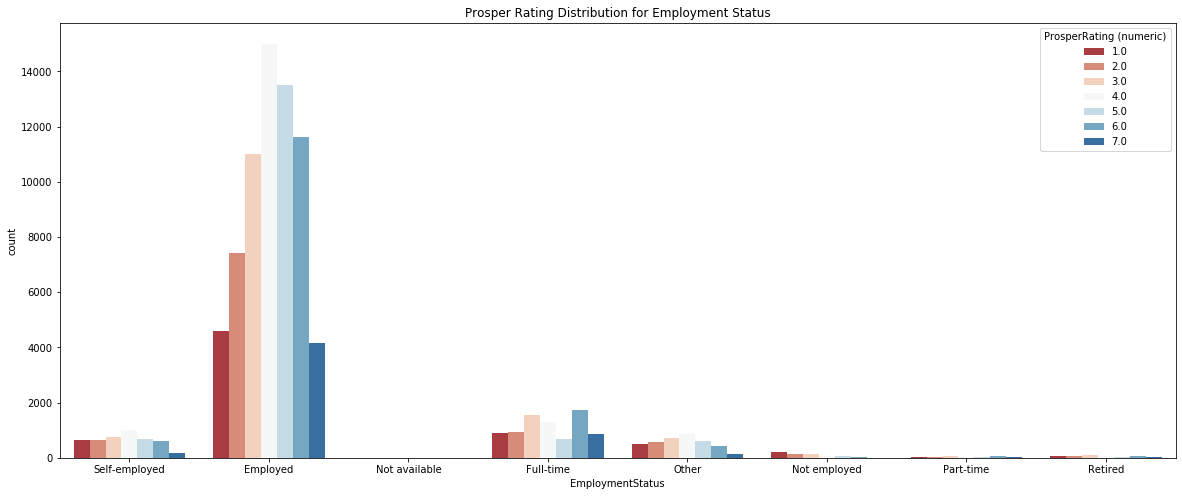

In [58]:
plt.figure(figsize = [20, 8])
sns.countplot(data = df_loan, x = 'EmploymentStatus', hue = 'ProsperRating (numeric)', palette='RdBu')
plt.title('Prosper Rating Distribution for Employment Status')

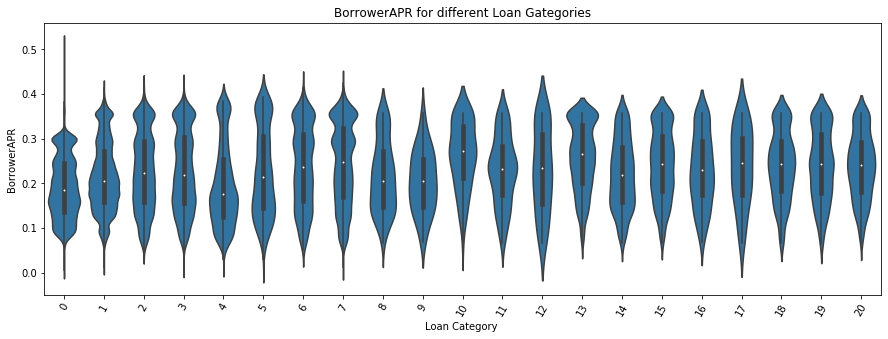

In [59]:
plt.figure(figsize = [15, 5])
sns.violinplot(data=df_loan,x='ListingCategory (numeric)', y='BorrowerAPR',color=base_color);
plt.xlabel('Loan Category ');
plt.ylabel('BorrowerAPR');
plt.title('BorrowerAPR for different Loan Gategories')
plt.xticks(rotation=60);

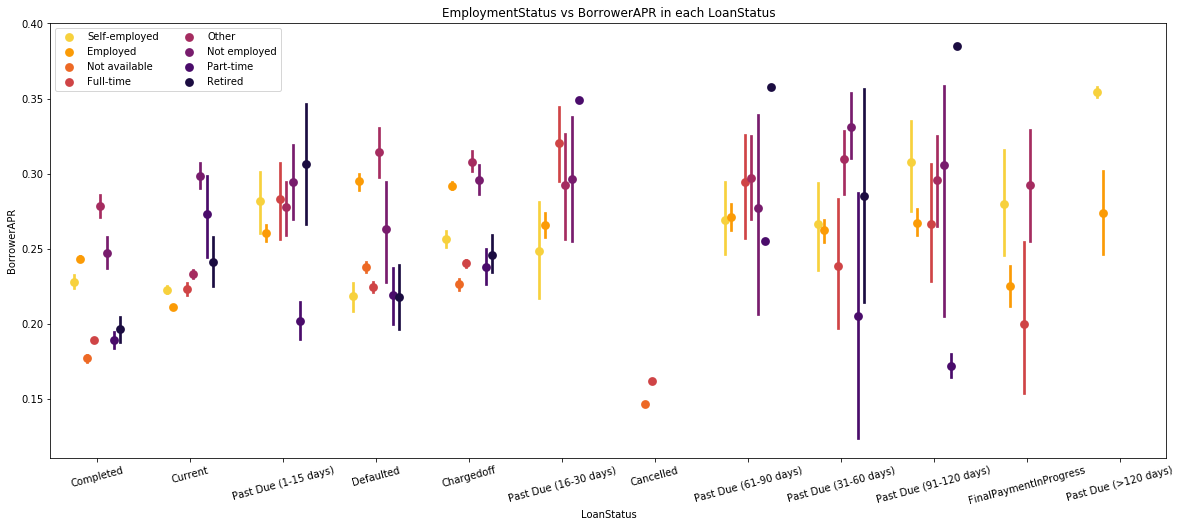

In [60]:
fig = plt.figure(figsize = [20,8])
ax = sns.pointplot(data = df_loan, x = 'LoanStatus', y = 'BorrowerAPR', hue = 'EmploymentStatus', linestyles = "",
                  dodge = 0.5, palette = 'inferno_r')
plt.title('EmploymentStatus vs BorrowerAPR in each LoanStatus')
plt.ylabel('BorrowerAPR')
plt.xticks(rotation=15)
plt.legend(ncol=2)
plt.show();

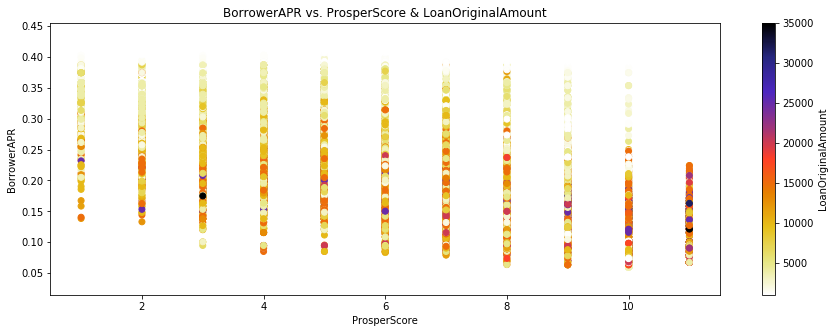

In [61]:
# BorrowerAPR vs. CreditScoreRangeUpper & CreditScoreRangeUpper
plt.figure(figsize = [15, 5]) 
cm = plt.cm.get_cmap('CMRmap_r')
plt.scatter(data = df_loan[df_loan['StatedMonthlyIncome'] <20000],\
            x = 'ProsperScore', y = 'BorrowerAPR', c ='LoanOriginalAmount', cmap=cm) 
plt.colorbar(label = 'LoanOriginalAmount')
plt.title('BorrowerAPR vs. ProsperScore & LoanOriginalAmount')
plt.xlabel('ProsperScore')
plt.ylabel('BorrowerAPR');

## Data Preprocessing

In [62]:
df['Term'] = df['Term'].astype('object')
df['ProsperScore'] = df['ProsperScore'].astype('object')

In [63]:
percent_missing = (df.isnull().sum() * 100 / len(df)).round(2)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})
missing_value_df["no_ofmissing_values"]=df.isnull().sum()

In [64]:
missing_value_df.sort_values(by = 'percent_missing', ascending = False)[0:30]

,column_name,percent_missing,no_ofmissing_values
GroupKey,GroupKey,88.29,100596
LoanFirstDefaultedCycleNumber,LoanFirstDefaultedCycleNumber,85.12,96985
ScorexChangeAtTimeOfListing,ScorexChangeAtTimeOfListing,83.39,95009
ProsperPrincipalOutstanding,ProsperPrincipalOutstanding,80.62,91852
ProsperPrincipalBorrowed,ProsperPrincipalBorrowed,80.62,91852
ProsperPaymentsOneMonthPlusLate,ProsperPaymentsOneMonthPlusLate,80.62,91852
ProsperPaymentsLessThanOneMonthLate,ProsperPaymentsLessThanOneMonthLate,80.62,91852
OnTimeProsperPayments,OnTimeProsperPayments,80.62,91852
TotalProsperLoans,TotalProsperLoans,80.62,91852
TotalProsperPaymentsBilled,TotalProsperPaymentsBilled,80.62,91852


In [65]:
df=df.drop(["ListingKey",'ListingNumber','ListingCreationDate','ClosedDate',"ProsperRating (Alpha)",'GroupKey','CurrentlyInGroup','DateCreditPulled','LoanKey','LoanNumber','LoanOriginationDate','MemberKey','LP_CollectionFees','LP_GrossPrincipalLoss','LP_NetPrincipalLoss','LP_NonPrincipalRecoverypayments','PercentFunded','Recommendations','InvestmentFromFriendsCount','InvestmentFromFriendsAmount','FirstRecordedCreditLine','LoanOriginationQuarter', 'BorrowerState'],axis=1)

In [66]:
df.shape

(113937, 58)

### Categorizing Target Variable

In [67]:
df["LoanStatus"].value_counts()

Current                   56576
Completed                 38074
Chargedoff                11992
Defaulted                  5018
Past Due (1-15 days)        806
Past Due (31-60 days)       363
Past Due (61-90 days)       313
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      205
Past Due (>120 days)         16
Cancelled                     5
Name: LoanStatus, dtype: int64

In [68]:
df['LoanStatus'] = df['LoanStatus'].replace(['Chargedoff', 'Defaulted', 'Past Due (1-15 days)', 'Past Due (31-60 days)',
                                             'Past Due (61-90 days)','Past Due (91-120 days)','Past Due (16-30 days)',
                                             'Past Due (>120 days)'],'Defaulted')
df['LoanStatus'] = df['LoanStatus'].replace('FinalPaymentInProgress','Completed')
print(df.LoanStatus.value_counts())

Current      56576
Completed    38279
Defaulted    19077
Cancelled        5
Name: LoanStatus, dtype: int64


In [69]:
df = df.drop(df[df['LoanStatus'] == 'Cancelled'].index)

In [70]:
df = df.reset_index()

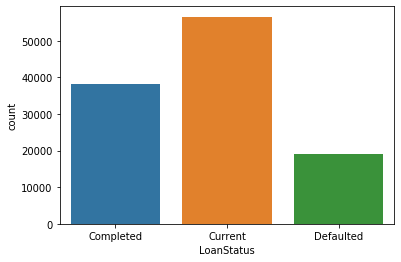

In [72]:
sns.countplot(df['LoanStatus']);

### Dropping Missing Values

In [73]:
df=df.dropna(thresh=df.shape[0]*0.5,how="all",axis=1)

In [74]:
df.shape

(113932, 49)

In [75]:
cateogry_columns=df.select_dtypes(include=['object']).columns.tolist()
integer_columns=df.select_dtypes(include=['int64','float64']).columns.tolist()
bool_columns=df.select_dtypes(include=['bool']).columns.tolist()

### Filling Missing Values

In [76]:
for column in df:
    if df[column].isnull().any():
        if(column in cateogry_columns):
            df[column]=df[column].fillna(df[column].mode()[0])
        else:
            df[column]=df[column].fillna(df[column].mean())

In [77]:
df.isnull().sum().sum()

0

In [78]:
percent_missing = (df.isnull().sum() * 100 / len(df)).round(2)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})
missing_value_df["no_of_missing_values"]=df.isnull().sum()

In [79]:
missing_value_df[:20]

,column_name,percent_missing,no_of_missing_values
index,index,0.0,0
Term,Term,0.0,0
LoanStatus,LoanStatus,0.0,0
BorrowerAPR,BorrowerAPR,0.0,0
BorrowerRate,BorrowerRate,0.0,0
LenderYield,LenderYield,0.0,0
EstimatedEffectiveYield,EstimatedEffectiveYield,0.0,0
EstimatedLoss,EstimatedLoss,0.0,0
EstimatedReturn,EstimatedReturn,0.0,0
ProsperRating (numeric),ProsperRating (numeric),0.0,0


In [80]:
cat_col=df[cateogry_columns].copy()

In [81]:
cat_col.head()

,Term,LoanStatus,ProsperScore,Occupation,EmploymentStatus,IncomeRange
0,36,Completed,4.0,Other,Self-employed,"$25,000-49,999"
1,36,Current,7.0,Professional,Employed,"$50,000-74,999"
2,36,Completed,4.0,Other,Not available,Not displayed
3,36,Current,9.0,Skilled Labor,Employed,"$25,000-49,999"
4,36,Current,4.0,Executive,Employed,"$100,000+"


In [82]:
final_cat_col=cat_col[['Term','ProsperScore','LoanStatus','Occupation','EmploymentStatus','IncomeRange']]

In [83]:
final_cat_col.head()

,Term,ProsperScore,LoanStatus,Occupation,EmploymentStatus,IncomeRange
0,36,4.0,Completed,Other,Self-employed,"$25,000-49,999"
1,36,7.0,Current,Professional,Employed,"$50,000-74,999"
2,36,4.0,Completed,Other,Not available,Not displayed
3,36,9.0,Current,Skilled Labor,Employed,"$25,000-49,999"
4,36,4.0,Current,Executive,Employed,"$100,000+"


In [84]:
df['LoanStatus'].value_counts()

Current      56576
Completed    38279
Defaulted    19077
Name: LoanStatus, dtype: int64

In [85]:
df["Occupation"].value_counts()

Other                          32201
Professional                   13628
Computer Programmer             4478
Executive                       4311
Teacher                         3759
                               ...  
Dentist                           68
Student - College Freshman        41
Student - Community College       28
Judge                             22
Student - Technical School        16
Name: Occupation, Length: 67, dtype: int64

In [86]:
df["EmploymentStatus"].value_counts()

Employed         69574
Full-time        26354
Self-employed     6134
Not available     5346
Other             3806
Part-time         1088
Not employed       835
Retired            795
Name: EmploymentStatus, dtype: int64

In [87]:
df['IncomeRange'].value_counts()

$25,000-49,999    32191
$50,000-74,999    31050
$100,000+         17337
$75,000-99,999    16916
Not displayed      7737
$1-24,999          7274
Not employed        806
$0                  621
Name: IncomeRange, dtype: int64

In [88]:
def ordinal_encoder(final_cat_col, feats): 
    for feat in feats:    
        feat_val = list(1+np.arange(final_cat_col[feat].nunique()))
        feat_key = list(final_cat_col[feat].sort_values().unique())
        feat_dict = dict(zip(feat_key, feat_val))
        final_cat_col[feat] = final_cat_col[feat].map(feat_dict)
    return final_cat_col

final_cat_col = ordinal_encoder(final_cat_col, final_cat_col.drop(['LoanStatus'],axis=1).columns)
final_cat_col.shape

(113932, 6)

In [89]:
final_cat_col.head()

,Term,ProsperScore,LoanStatus,Occupation,EmploymentStatus,IncomeRange
0,2,4,Completed,36,8,4
1,2,7,Current,42,1,5
2,2,4,Completed,36,3,7
3,2,9,Current,51,1,4
4,2,4,Current,20,1,3


In [90]:
df=df.drop(['LoanStatus','Occupation','EmploymentStatus','IncomeRange','Term','ProsperScore'],axis=1)

In [91]:
df=pd.concat([df,final_cat_col],axis=1)

In [92]:
df.head()

,index,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ListingCategory (numeric),EmploymentStatusDuration,IsBorrowerHomeowner,CreditScoreRangeLower,CreditScoreRangeUpper,CurrentCreditLines,OpenCreditLines,TotalCreditLinespast7years,OpenRevolvingAccounts,OpenRevolvingMonthlyPayment,InquiriesLast6Months,TotalInquiries,CurrentDelinquencies,AmountDelinquent,DelinquenciesLast7Years,PublicRecordsLast10Years,PublicRecordsLast12Months,RevolvingCreditBalance,BankcardUtilization,AvailableBankcardCredit,TotalTrades,TradesNeverDelinquent (percentage),TradesOpenedLast6Months,DebtToIncomeRatio,IncomeVerifiable,StatedMonthlyIncome,LoanCurrentDaysDelinquent,LoanMonthsSinceOrigination,LoanOriginalAmount,MonthlyLoanPayment,LP_CustomerPayments,LP_CustomerPrincipalPayments,LP_InterestandFees,LP_ServiceFees,Investors,Term,ProsperScore,LoanStatus,Occupation,EmploymentStatus,IncomeRange
0,0,0.16516,0.1580,0.1380,0.168661,0.080306,0.096068,4.072243,0,2.000000,True,640.0,659.0,5.000000,4.000000,12.0,1,24.0,3.0,3.0,2.0,472.00000,4.0,0.0,0.000000,0.000000,0.000000,1500.000000,11.000000,0.8100,0.000000,0.17,True,3083.333333,0,78,9425,330.43,11396.14,9425.00,1971.14,-133.18,258,2,4,Completed,36,8,4
1,1,0.12016,0.0920,0.0820,0.079600,0.024900,0.054700,6.000000,2,44.000000,False,680.0,699.0,14.000000,14.000000,29.0,13,389.0,3.0,5.0,0.0,0.00000,0.0,1.0,0.000000,3989.000000,0.210000,10266.000000,29.000000,1.0000,2.000000,0.18,True,6125.000000,0,0,10000,318.93,0.00,0.00,0.00,0.00,1,2,7,Current,42,1,5
2,2,0.28269,0.2750,0.2400,0.168661,0.080306,0.096068,4.072243,0,96.072203,False,480.0,499.0,10.317205,9.260185,3.0,0,0.0,0.0,1.0,1.0,984.51632,0.0,0.0,0.015094,17598.865807,0.561313,11210.222724,23.230111,0.8859,0.802335,0.06,True,2083.333333,0,86,3001,123.32,4186.63,3001.00,1185.63,-24.20,41,2,4,Completed,36,3,7
3,3,0.12528,0.0974,0.0874,0.084900,0.024900,0.060000,6.000000,16,113.000000,True,800.0,819.0,5.000000,5.000000,29.0,7,115.0,0.0,1.0,4.0,10056.00000,14.0,0.0,0.000000,1444.000000,0.040000,30754.000000,26.000000,0.7600,0.000000,0.15,True,2875.000000,0,16,10000,321.45,5143.20,4091.09,1052.11,-108.01,158,2,9,Current,51,1,4
4,4,0.24614,0.2085,0.1985,0.183160,0.092500,0.090660,3.000000,2,44.000000,True,680.0,699.0,19.000000,19.000000,49.0,6,220.0,1.0,9.0,0.0,0.00000,0.0,0.0,0.000000,6193.000000,0.810000,695.000000,39.000000,0.9500,2.000000,0.26,True,9583.333333,0,6,15000,563.97,2819.85,1563.22,1256.63,-60.27,20,2,4,Current,20,1,3


In [93]:
df.shape

(113932, 49)

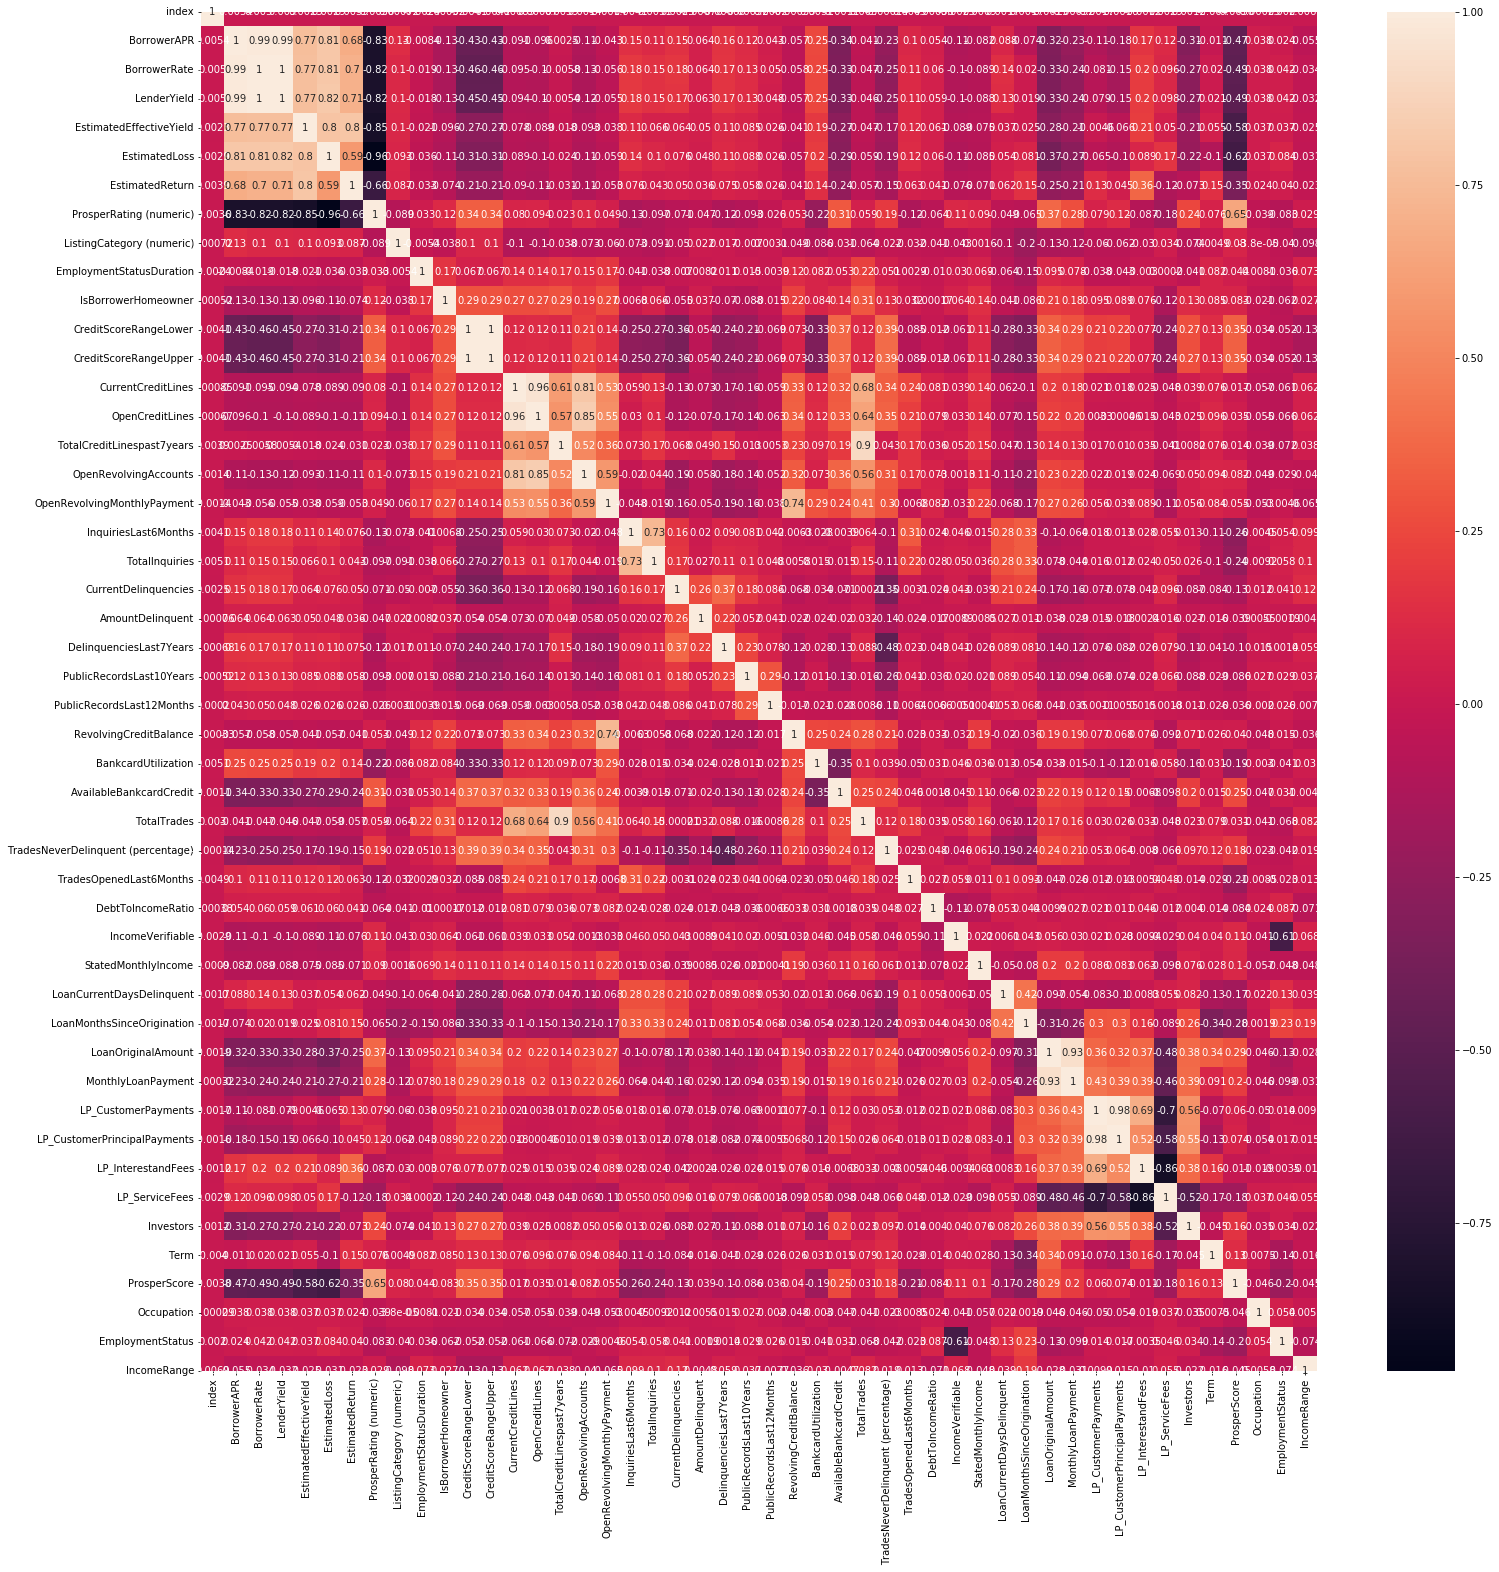

In [94]:
plt.figure(figsize = (25, 25))
sns.heatmap(df.corr(), annot = True)
plt.show()

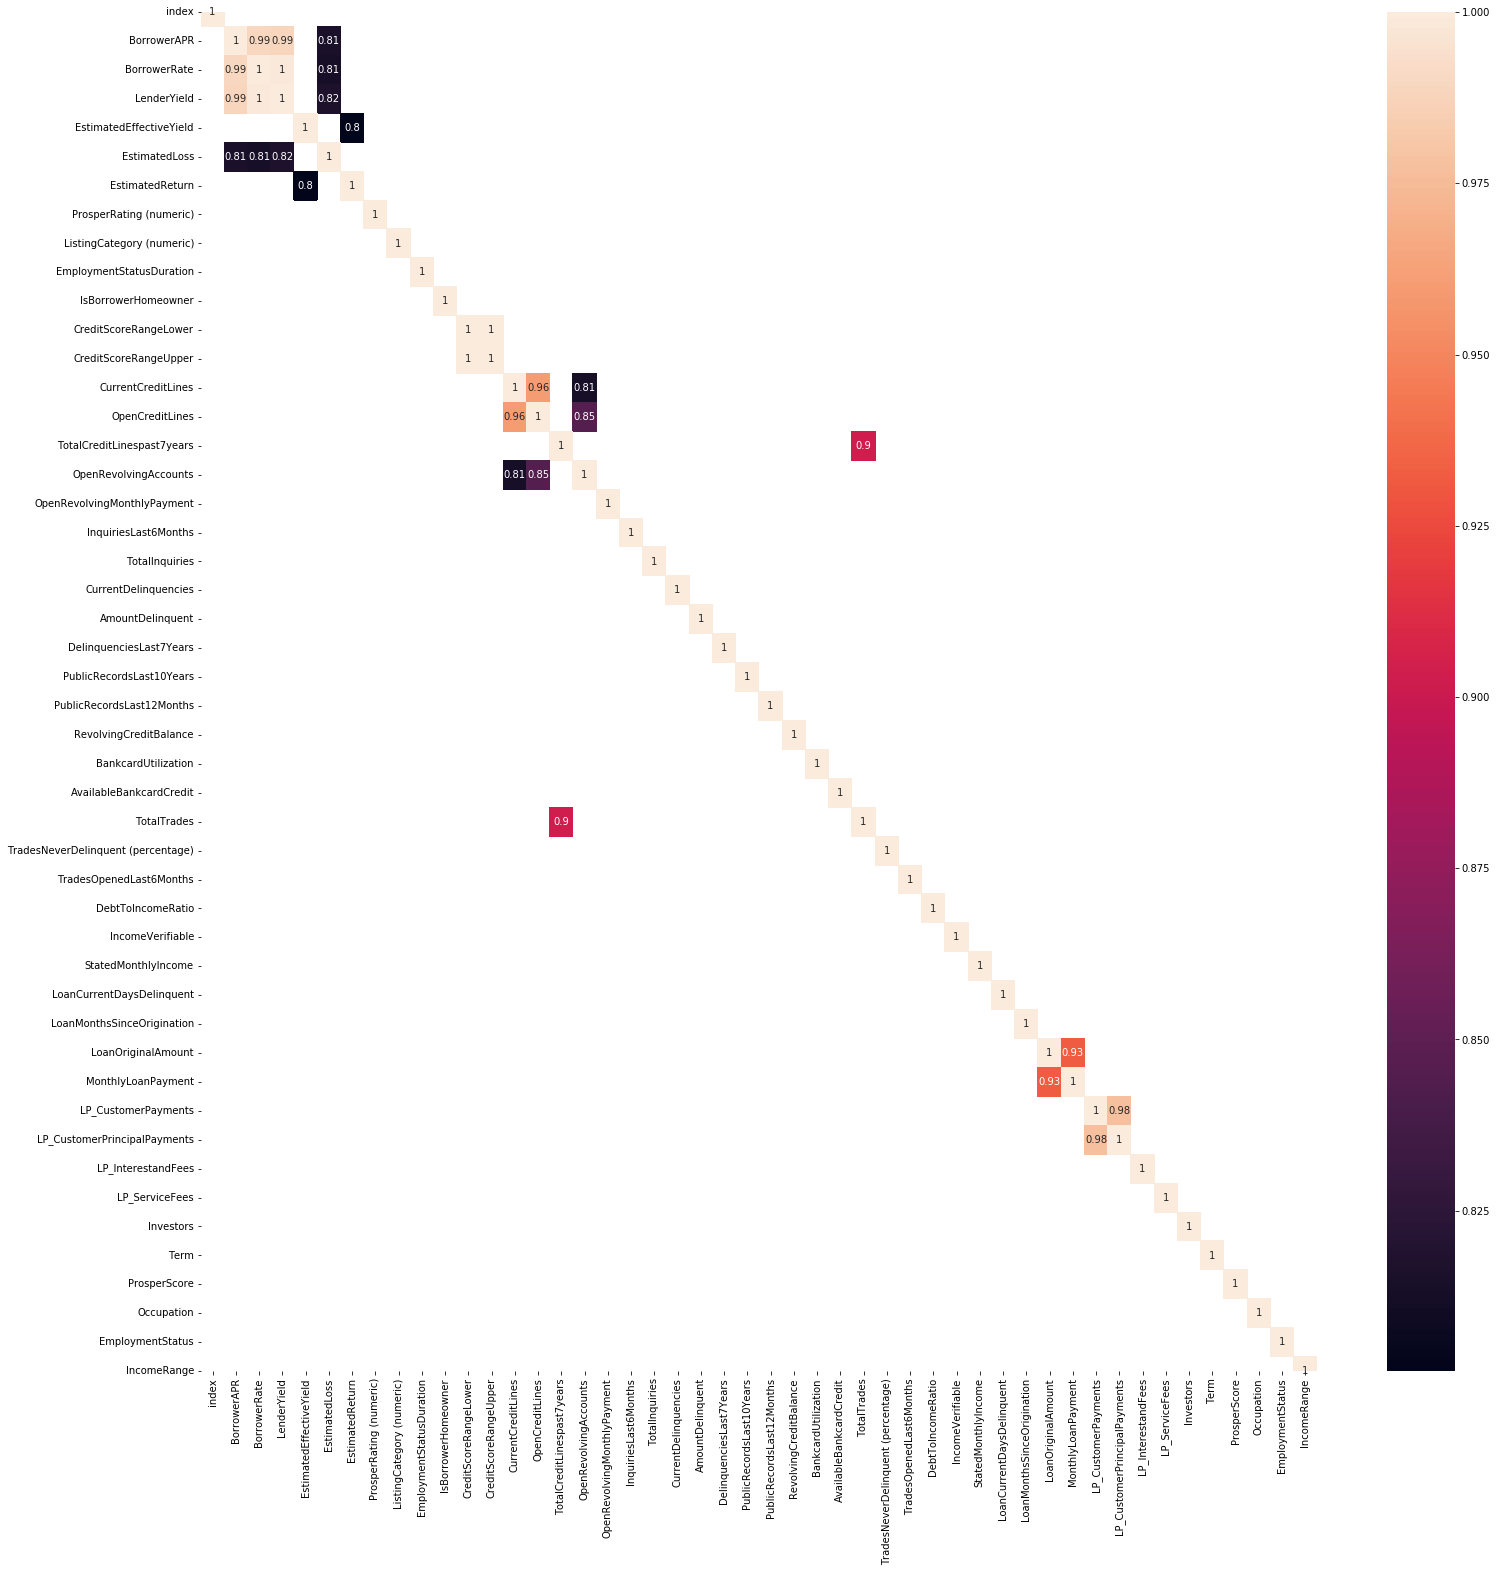

In [95]:
plt.figure(figsize = (25, 25))
sns.heatmap(df.corr()[df.corr() > 0.8], annot = True)
plt.show()

In [96]:
df = df.drop(['BorrowerAPR', 'LenderYield', 'EstimatedLoss', 'CreditScoreRangeLower', 'OpenCreditLines',
              'OpenRevolvingAccounts', 'TotalCreditLinespast7years', 'LP_CustomerPrincipalPayments',
              'LoanMonthsSinceOrigination'], axis = 1)

In [97]:
df.shape

(113932, 40)

In [98]:
from sklearn.model_selection import train_test_split
X= df.drop(['LoanStatus'], axis=1)
y = df['LoanStatus']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('X_train :', X_train.shape)
print('X_test :', X_test.shape)
print('y_train :', y_train.shape)
print('y_test :', y_test.shape)

X_train : (79752, 39)
X_test : (34180, 39)
y_train : (79752,)
y_test : (34180,)


In [99]:
from sklearn.metrics import (accuracy_score, 
                            classification_report,
                            recall_score, precision_score, f1_score,
                            confusion_matrix)
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier

In [100]:
def modelling(X_train, y_train, X_test, y_test, **kwargs):
    scores = {}
    models = []
    if 'dtf' in kwargs.keys() and kwargs['dtf']:
        dtf=DecisionTreeClassifier()
        dtf.fit(X_train,y_train)
        y_pred = dtf.predict(X_test)
        scores['dtf'] = [accuracy_score(y_test, y_pred)]
#         scores['extree']['roc_auc'] = roc_auc_score(y_test, y_pred)
    return scores

In [101]:
modelling(X_train,y_train, X_test, y_test, dtf=True)

{'dtf': [0.9811878291398478]}

In [102]:
import plotly.graph_objs as go
import plotly.tools as tls
import plotly.figure_factory as ff

import plotly.express as px
import plotly.offline as py
def model_performance(model, y_test, y_hat) : 
    conf_matrix = confusion_matrix(y_test, y_hat)
    trace1 = go.Heatmap(z = conf_matrix  ,x = ["0 (pred)","1 (pred)", "2 (pred)"],
                        y = ["0 (true)","1 (true)", "2 (true)"],xgap = 2, ygap = 2, 
                        colorscale = 'Rainbow', showscale  = False)

    #Show metrics
    Accuracy  =  accuracy_score(y_test, y_hat)
    Precision =  precision_score(y_test, y_pred, average= 'weighted')
    Recall    =  recall_score(y_test, y_pred, average= 'weighted')
    F1_score  =  f1_score(y_test, y_pred, average= 'weighted')

    show_metrics = pd.DataFrame(data=[[Accuracy , Precision, Recall, F1_score]])
    show_metrics = show_metrics.T

    colors = ['gold', 'lightgreen', 'lightcoral', 'lightskyblue']
    trace2 = go.Bar(x = (show_metrics[0].values), 
                   y = ['Accuracy', 'Precision', 'Recall', 'F1_score'], text = np.round_(show_metrics[0].values,4),
                    textposition = 'auto',
                   orientation = 'h', opacity = 0.8,marker=dict(
            color=colors,
            line=dict(color='#000000',width=1.5)))
 
     
    #plots
    model = model
    
    #Subplots
    fig = tls.make_subplots(rows=2, cols=1, print_grid=False, 
                          subplot_titles=('Confusion Matrix',
                                        'Metrics',
                                        ))
    
    fig.append_trace(trace1,1,1)
    fig.append_trace(trace2,2,1)
    
    fig['layout'].update(showlegend = False, title = '<b>Model performance report</b><br>'+str(model),
                        autosize = True, height = 800,width = 800,
                        plot_bgcolor = 'rgba(240,240,240, 0.95)',
                        paper_bgcolor = 'rgba(240,240,240, 0.95)',
                        # margin = dict(b = 100)
                        )
    fig.layout.titlefont.size = 14
    
    py.iplot(fig)

In [103]:
dtf=DecisionTreeClassifier()
dtf.fit(X_train,y_train)
# dtf.score(X_test,y_test)
y_pred = dtf.predict(X_test)

In [104]:
model_performance(dtf,y_test, y_pred)

C:\Users\Owner\Anaconda3\lib\site-packages\plotly\tools.py:465: DeprecationWarning:

plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead



In [105]:
 print('Train accuracy: ', dtf.score(X_train, y_train))

Train accuracy:  1.0


In [106]:
 print('Test accuracy: ', dtf.score(X_test, y_test))

Test accuracy:  0.9810415447630193


In [107]:
y_pred=dtf.predict(X_train)

In [108]:
print(classification_report(y_train,y_pred))

              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00     26810
     Current       1.00      1.00      1.00     39556
   Defaulted       1.00      1.00      1.00     13386

    accuracy                           1.00     79752
   macro avg       1.00      1.00      1.00     79752
weighted avg       1.00      1.00      1.00     79752



In [109]:
y_pred=dtf.predict(X_test)

In [110]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

   Completed       0.97      0.97      0.97     11469
     Current       0.98      0.98      0.98     17020
   Defaulted       1.00      1.00      1.00      5691

    accuracy                           0.98     34180
   macro avg       0.98      0.98      0.98     34180
weighted avg       0.98      0.98      0.98     34180



In [112]:
from sklearn.model_selection import GridSearchCV

tuned_parms = {'criterion' : ['entropy', 'gini'],
              'max_depth' : range(2, 10),
              'min_samples_split' : range(5, 10, 15)}
dtf = DecisionTreeClassifier(random_state = 10)
grid = GridSearchCV(estimator = dtf, param_grid = tuned_parms, cv = 5, scoring = 'roc_auc')
grid_model = grid.fit(X_train, y_train)

In [113]:
grid_model.best_params_

{'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 5}

In [114]:
dt_best = DecisionTreeClassifier(criterion = 'entropy', max_depth = 2, min_samples_split = 2)
dt_best.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2)

In [115]:
y_test_pred = dt_best.predict(X_test)

model_performance(dt_best, y_test, y_test_pred)

C:\Users\Owner\Anaconda3\lib\site-packages\plotly\tools.py:465: DeprecationWarning:

plotly.tools.make_subplots is deprecated, please use plotly.subplots.make_subplots instead



In [116]:
feat_imp=pd.DataFrame(dt_best.feature_importances_,index=X_train.columns,columns=['Importance'])
feat_imp=feat_imp.reset_index().sort_values('Importance',ascending=False)

In [117]:
feat_imp

,index,Importance
27,LoanCurrentDaysDelinquent,0.796333
30,LP_CustomerPayments,0.203667
29,MonthlyLoanPayment,0.000000
22,TradesNeverDelinquent (percentage),0.000000
23,TradesOpenedLast6Months,0.000000
24,DebtToIncomeRatio,0.000000
25,IncomeVerifiable,0.000000
26,StatedMonthlyIncome,0.000000
28,LoanOriginalAmount,0.000000
0,index,0.000000


In [118]:
y_xgb = y.replace({'Completed' : 0, 'Current' : 1, 'Defaulted' : 2})

In [119]:
X_train, X_test, y_xgb_train, y_xgb_test = train_test_split(X, y_xgb, test_size = 0.3, random_state = 10)

print('X_train :', X_train.shape)
print('X_test :', X_test.shape)
print('y_xgb_train :', y_xgb_train.shape)
print('y_xgb_test :', y_xgb_test.shape)

X_train : (79752, 39)
X_test : (34180, 39)
y_xgb_train : (79752,)
y_xgb_test : (34180,)


In [120]:
def modelling(X_train, y_train, X_test, y_test, **kwargs):
    scores = {}
    models = []
    if 'xgb' in kwargs.keys() and kwargs['xgb']:
        xgb = XGBClassifier()
        xgb.fit(X_train._get_numeric_data(), np.ravel(y_train, order='C'))
        y_pred = xgb.predict(X_test._get_numeric_data())
        scores['xgb']= [accuracy_score(y_test, y_pred)]
#         scores['xgb']['roc_auc'] = roc_auc_score(y_test, y_pred)
    return scores

In [121]:
modelling(X_train, y_xgb_train, X_test, y_xgb_test, xgb=True)

[19:32:10] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


{'xgb': [0.9935634874195436]}

In [122]:
xgb = XGBClassifier()
xgb.fit(X_train._get_numeric_data(), np.ravel(y_xgb_train, order='C'))
y_xgb_pred_test = xgb.predict(X_test)
y_xgb_pred_train = xgb.predict(X_train)

[19:33:39] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'multi:softprob' was changed from 'merror' to 'mlogloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


In [123]:
print(classification_report(y_xgb_test, y_xgb_pred_test))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     11363
           1       1.00      0.99      0.99     17069
           2       1.00      1.00      1.00      5748

    accuracy                           0.99     34180
   macro avg       0.99      1.00      0.99     34180
weighted avg       0.99      0.99      0.99     34180



In [124]:
print(classification_report(y_xgb_train,y_xgb_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26916
           1       1.00      1.00      1.00     39507
           2       1.00      1.00      1.00     13329

    accuracy                           1.00     79752
   macro avg       1.00      1.00      1.00     79752
weighted avg       1.00      1.00      1.00     79752



In [125]:
feat_imp=pd.DataFrame(xgb.feature_importances_,index=X_train.columns,columns=['Importance'])
feat_imp=feat_imp.reset_index().sort_values('Importance',ascending=False)

In [126]:
feat_imp

,index,Importance
27,LoanCurrentDaysDelinquent,0.453034
37,EmploymentStatus,0.364620
28,LoanOriginalAmount,0.043328
30,LP_CustomerPayments,0.031854
32,LP_ServiceFees,0.027439
2,EstimatedEffectiveYield,0.014475
4,ProsperRating (numeric),0.014210
5,ListingCategory (numeric),0.012160
34,Term,0.007198
29,MonthlyLoanPayment,0.006741


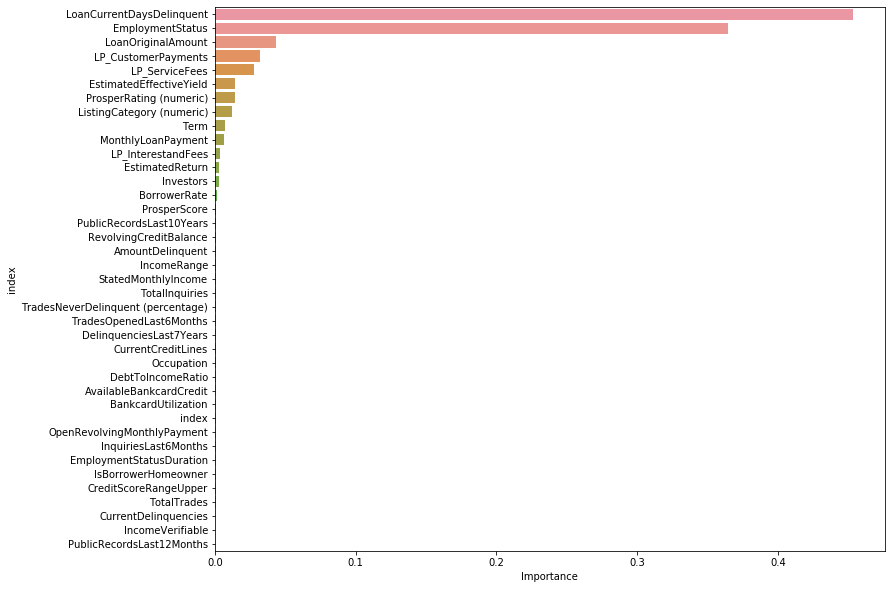

In [128]:
plt.figure(figsize=(12,10))
sns.barplot(data=feat_imp,x='Importance',y='index')
plt.show()

In [119]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

params = {'n_estimators' : [100, 120, 150],
'learning_rate' : [0.1, 0.01, 0.001, 0.15, 0.015], 
'gamma' : [2, 3, 4, 5, 6],
'max_depth' : [2, 3, 4, 5, 6]}

xgb = XGBClassifier()
grid = HalvingGridSearchCV(estimator = xgb, param_grid = params, cv = 5)
grid_model = grid.fit(X_train, y_xgb_train)

In [120]:
grid_model.best_params_

{'gamma': 2, 'learning_rate': 0.15, 'max_depth': 4, 'n_estimators': 100}

In [130]:
def modelling(X_train, y_train, X_test, y_test, **kwargs):
    scores = {}
    models = []
    if 'xgb' in kwargs.keys() and kwargs['xgb']:
        xgb = XGBClassifier(n_estimators = 100, learning_rate = 0.15, gamma = 2, max_depth = 4)
        xgb.fit(X_train._get_numeric_data(), np.ravel(y_train, order='C'))
        y_pred = xgb.predict(X_test._get_numeric_data())
        scores['xgb']= [accuracy_score(y_test, y_pred)]
#         scores['xgb']['roc_auc'] = roc_auc_score(y_test, y_pred)
    return scores

In [131]:
modelling(X_train, y_xgb_train, X_test, y_xgb_test, xgb=True)

{'xgb': [0.9923639555295495]}

In [132]:
print(classification_report(y_xgb_test, y_xgb_pred_test))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     11363
           1       1.00      0.99      0.99     17069
           2       1.00      1.00      1.00      5748

    accuracy                           0.99     34180
   macro avg       0.99      1.00      0.99     34180
weighted avg       0.99      0.99      0.99     34180



In [133]:
print(classification_report(y_xgb_train,y_xgb_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26916
           1       1.00      1.00      1.00     39507
           2       1.00      1.00      1.00     13329

    accuracy                           1.00     79752
   macro avg       1.00      1.00      1.00     79752
weighted avg       1.00      1.00      1.00     79752



In [135]:
def modelling(X_train, y_train, X_test, y_test, **kwargs):
    scores = {}
    models = []
    if 'rf' in kwargs.keys() and kwargs['rf']:
        rf = RandomForestClassifier(n_estimators=200)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        scores['rf']= [accuracy_score(y_test, y_pred)]
#         scores['rf']['roc_auc'] = roc_auc_score(y_test, y_pred)
    return scores

In [123]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

In [124]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

   Completed       0.34      0.10      0.16     11469
     Current       0.50      0.90      0.64     17020
   Defaulted       0.19      0.00      0.00      5691

    accuracy                           0.48     34180
   macro avg       0.34      0.33      0.27     34180
weighted avg       0.39      0.48      0.37     34180



In [125]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00     26810
     Current       1.00      1.00      1.00     39556
   Defaulted       1.00      1.00      1.00     13386

    accuracy                           1.00     79752
   macro avg       1.00      1.00      1.00     79752
weighted avg       1.00      1.00      1.00     79752



In [126]:
params = {'criterion' : ['entropy', 'gini'],
'n_estimators' : [90, 100, 150, 200],
'max_depth' : [10, 15, 20],
'min_samples_split' : [2, 5, 8]}
 
rf = RandomForestClassifier()
grid = HalvingGridSearchCV(estimator = rf, param_grid = params, cv = 5)
grid_model = grid.fit(X_train, y_train)

In [128]:
grid_model.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_split': 8,
 'n_estimators': 200}

In [138]:
rf = RandomForestClassifier(criterion = 'entropy', max_depth = 10, min_samples_split = 8, n_estimators = 200)
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

In [139]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

   Completed       0.00      0.00      0.00     11469
     Current       0.50      1.00      0.66     17020
   Defaulted       0.00      0.00      0.00      5691

    accuracy                           0.50     34180
   macro avg       0.17      0.33      0.22     34180
weighted avg       0.25      0.50      0.33     34180



In [140]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

   Completed       1.00      0.00      0.00     26810
     Current       0.50      1.00      0.66     39556
   Defaulted       1.00      0.00      0.00     13386

    accuracy                           0.50     79752
   macro avg       0.83      0.33      0.22     79752
weighted avg       0.75      0.50      0.33     79752

